![alt text](header.png)

## Notebook 2 | Model Compression in Practice

> **Workshop: From Algorithm to Hardware: Machine Learning in Embedded Systems | April 2026**   

This notebook demonstrates pruning, quantization-aware training and knowledge distillation on MNIST MLP. These are the same techniques available in KalEdge.

### Setup: load and train the baseline

We start from the same baseline as Notebook 1.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf

# gpus = tf.config.list_physical_devices('GPU')
# if gpus:
#     for gpu in gpus:
#         tf.config.experimental.set_memory_growth(gpu, True)
# else:
#     print("No GPU found. Running on CPU.")


tf.random.set_seed(42)
np.random.seed(42)

2026-04-19 21:35:54.982745: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-19 21:35:54.984859: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-19 21:35:55.027238: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-19 21:35:55.028152: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-19 21:35:55.737624: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [2]:
(X_tr, y_tr), (X_te, y_te) = mnist.load_data()
X_tr = X_tr.reshape(-1, 784).astype('float32') / 255.0
X_te = X_te.reshape(-1, 784).astype('float32') / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr, test_size=0.1, random_state=42, stratify=y_tr
)

y_train_cat = to_categorical(y_train, 10)
y_val_cat   = to_categorical(y_val,   10)
y_test_cat  = to_categorical(y_te,    10)

y_train_cat = y_train_cat.astype('float32')
y_val_cat = y_val_cat.astype('float32')
y_test_cat = y_test_cat.astype('float32')


In [3]:

def build_baseline():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

baseline = build_baseline()
baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
             epochs=20, batch_size=64, verbose=0)

_, acc = baseline.evaluate(X_te, y_test_cat, verbose=0)
print(f'Baseline accuracy: {acc:.4f}  |  Params: {baseline.count_params():,}')

Baseline accuracy: 0.9712  |  Params: 52,650


### 1. Pruning: zeroing low-magnitude weights

Pruning removes weights that contribute little to the output. The key parameters are:
- **final_sparsity**: target fraction of zero weights (e.g. 0.5 = 50% zeros)
- **begin_step / end_step**: when pruning starts and ends during training

The schedule gradually increases sparsity from 0 to `final_sparsity` between `begin_step` and `end_step`.

In [4]:
import math

FINAL_SPARSITY = 0.5
EPOCHS         = 15
BATCH          = 64

steps_per_epoch = math.ceil(len(X_train) / BATCH)
total_steps     = EPOCHS * steps_per_epoch
begin_step      = int(total_steps * 0.10)
end_step        = int(total_steps * 0.90)

pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.0,
    final_sparsity=FINAL_SPARSITY,
    begin_step=begin_step,
    end_step=end_step,
)

pruned_model = tfmot.sparsity.keras.prune_low_magnitude(
    build_baseline(), pruning_schedule=pruning_schedule
)
pruned_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]
pruned_model.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
                 epochs=EPOCHS, batch_size=BATCH, verbose=0, callbacks=callbacks)

# Remove pruning wrappers to get the final pruned model
pruned_stripped = tfmot.sparsity.keras.strip_pruning(pruned_model)

# Compile the stripped model before evaluating
pruned_stripped.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

_, acc_pruned = pruned_stripped.evaluate(X_te, y_test_cat, verbose=0)
zeros = sum(np.sum(w.numpy() == 0) for w in pruned_stripped.weights)
total = sum(w.numpy().size for w in pruned_stripped.weights)
sparsity = zeros / total

print(f'Pruned accuracy : {acc_pruned:.4f}')
print(f'Actual sparsity : {sparsity:.1%}')
print(f'Accuracy drop   : {acc - acc_pruned:.4f}')

Pruned accuracy : 0.9747
Actual sparsity : 49.9%
Accuracy drop   : -0.0035


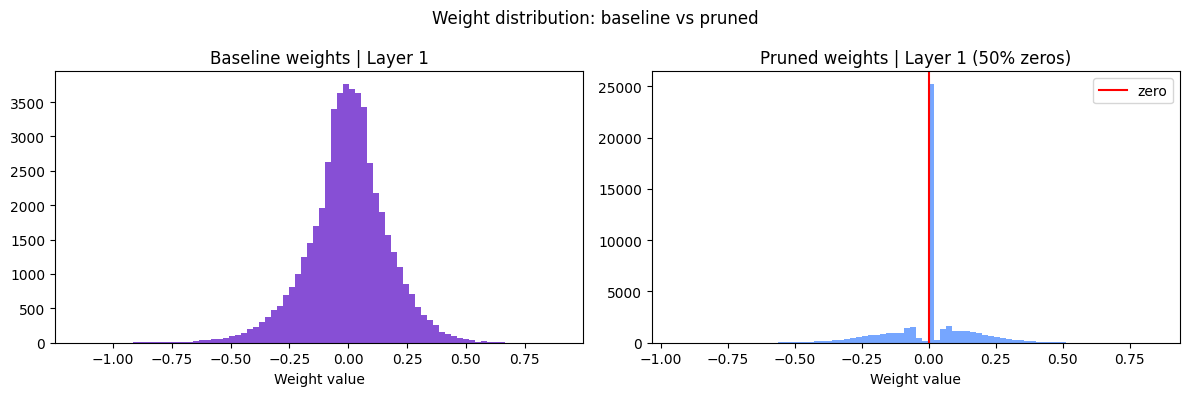

In [5]:
# Visualize weight distribution before and after pruning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

w_base   = baseline.layers[0].get_weights()[0].flatten()
w_pruned = pruned_stripped.layers[0].get_weights()[0].flatten()

axes[0].hist(w_base,   bins=80, color='#5405C4', alpha=0.7)
axes[0].set_title('Baseline weights | Layer 1')
axes[0].set_xlabel('Weight value')

axes[1].hist(w_pruned, bins=80, color='#3C80FF', alpha=0.7)
axes[1].axvline(0, color='red', linewidth=1.5, label='zero')
axes[1].set_title(f'Pruned weights | Layer 1 ({sparsity:.0%} zeros)')
axes[1].set_xlabel('Weight value')
axes[1].legend()

plt.suptitle('Weight distribution: baseline vs pruned', fontsize=12)
plt.tight_layout()
plt.show()

### 2. Quantization-Aware Training with QKeras

Quantization replaces 32-bit floats with fixed-point numbers: `ap_fixed<W, I>` where W is the total bits and I is the integer bits.

- `ap_fixed<8,4>` uses 8 bits total, 4 for the integer part
- Lower bit-width = fewer FPGA resources, but potential accuracy loss

QKeras trains the model while simulating quantization, so the accuracy reflects the quantized version.

In [6]:
from qkeras import QDense, QActivation
from qkeras.quantizers import quantized_bits

WBITS = 8
IBITS = 0

def build_qkeras_model(wbits=8, ibits=0, num_classes=10):
    return tf.keras.Sequential([
        QDense(64, input_shape=(784,),
               kernel_quantizer=quantized_bits(wbits, ibits),
               bias_quantizer=quantized_bits(wbits, ibits)),
        QActivation(f'quantized_relu({wbits},{ibits})'),
        QDense(32,
               kernel_quantizer=quantized_bits(wbits, ibits),
               bias_quantizer=quantized_bits(wbits, ibits)),
        QActivation(f'quantized_relu({wbits},{ibits})'),
        QDense(num_classes,
               kernel_quantizer=quantized_bits(wbits, ibits),
               bias_quantizer=quantized_bits(wbits, ibits),
               activation='softmax'),  # softmax inside QDense for hls4ml compatibility
    ])

qat_model = build_qkeras_model(wbits=WBITS, ibits=IBITS)
qat_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
qat_model.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
              epochs=20, batch_size=64, verbose=0)

_, acc_qat = qat_model.evaluate(X_te, y_test_cat, verbose=0)
print(f'QAT accuracy (bits={WBITS}, ibits={IBITS}) : {acc_qat:.4f}')
print(f'Accuracy drop vs baseline                 : {acc - acc_qat:.4f}')

QAT accuracy (bits=8, ibits=0) : 0.9683
Accuracy drop vs baseline                 : 0.0029


Training models with wbits=8 on CPU…
Epoch 1/15
1688/1688 [==============================] - 9s 4ms/step - loss: 0.3797 - accuracy: 0.9110 - val_loss: 0.1851 - val_accuracy: 0.9487
Epoch 2/15
1688/1688 [==============================] - 5s 3ms/step - loss: 0.1467 - accuracy: 0.9583 - val_loss: 0.1437 - val_accuracy: 0.9565
Epoch 3/15
1688/1688 [==============================] - 5s 3ms/step - loss: 0.1102 - accuracy: 0.9679 - val_loss: 0.1298 - val_accuracy: 0.9610
Epoch 4/15
1688/1688 [==============================] - 6s 3ms/step - loss: 0.0916 - accuracy: 0.9727 - val_loss: 0.1336 - val_accuracy: 0.9602
Epoch 5/15
1688/1688 [==============================] - 5s 3ms/step - loss: 0.0785 - accuracy: 0.9763 - val_loss: 0.1226 - val_accuracy: 0.9632
Epoch 6/15
1688/1688 [==============================] - 5s 3ms/step - loss: 0.0702 - accuracy: 0.9786 - val_loss: 0.1327 - val_accuracy: 0.9597
Epoch 7/15
1688/1688 [==============================] - 5s 3ms/step - loss: 0.0623 - accuracy: 0.98

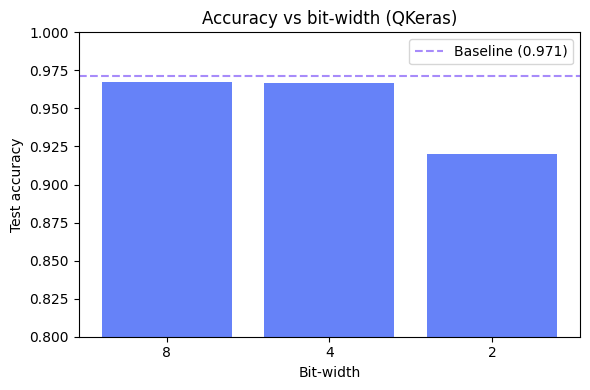

In [7]:

results = {}
for wbits in [8, 4, 2]:
    print(f"Training models with wbits={wbits} on CPU…")
    m = build_qkeras_model(wbits=wbits, ibits=0)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    m.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=15,
        batch_size=32,
        verbose=1
    )
    
    _, a = m.evaluate(X_te, y_test_cat, verbose=0)
    results[wbits] = a
    print(f'  bits={wbits}: accuracy={a:.4f}')


fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(k) for k in results.keys()], list(results.values()), color='#4B6CF7', alpha=0.85)
if 'acc' in globals():
    ax.axhline(acc, color='#A78BFA', linestyle='--', label=f'Baseline ({acc:.3f})')
ax.set_xlabel('Bit-width')
ax.set_ylabel('Test accuracy')
ax.set_title('Accuracy vs bit-width (QKeras)')
ax.legend()
ax.set_ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

### 3. Knowledge Distillation | Learning from a teacher

Instead of training the student from scratch, KD uses the teacher's output probabilities as soft labels. The student learns both the hard labels (ground truth) and the soft labels (teacher's confidence distribution).

- **Temperature**: higher values soften the teacher's probabilities, revealing more information about class relationships
- **Alpha**: balances the student loss (hard labels) vs distillation loss (soft labels)

In [8]:
# Knowledge Distillation class
from distiller import Distiller

In [9]:
# Build a smaller student
def build_student():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

student = build_student()
print(f'Student params : {student.count_params():,}')
print(f'Baseline params: {baseline.count_params():,}')
print(f'Compression    : {1 - student.count_params()/baseline.count_params():.0%} fewer parameters')

train_labels = np.argmax(y_train_cat, axis=1)

distiller = Distiller(student=student, teacher=baseline)
distiller.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
    student_loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    distillation_loss_fn=tf.keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=4,
)

history_kd = distiller.fit(X_train, train_labels,
              validation_data=(X_val, np.argmax(y_val_cat, axis=1)),
              epochs=30, batch_size=64, verbose=1)

y_pred_kd = np.argmax(student.predict(X_te, verbose=0), axis=1)
acc_kd    = np.mean(y_pred_kd == y_te)
print(f'KD student accuracy : {acc_kd:.4f}')
print(f'Baseline accuracy   : {acc:.4f}')
print(f'Accuracy drop       : {acc - acc_kd:.4f}')

Student params : 12,730
Baseline params: 52,650
Compression    : 76% fewer parameters
Epoch 1/30
844/844 [==============================] - 2s 1ms/step - sparse_categorical_accuracy: 0.8549 - student_loss: 0.5407 - distillation_loss: 7.9633e-04 - val_sparse_categorical_accuracy: 0.9113 - val_student_loss: 0.4074
Epoch 2/30
844/844 [==============================] - 1s 1ms/step - sparse_categorical_accuracy: 0.9189 - student_loss: 0.2859 - distillation_loss: 4.0565e-04 - val_sparse_categorical_accuracy: 0.9187 - val_student_loss: 0.3034
Epoch 3/30
844/844 [==============================] - 1s 1ms/step - sparse_categorical_accuracy: 0.9281 - student_loss: 0.2535 - distillation_loss: 3.5746e-04 - val_sparse_categorical_accuracy: 0.9293 - val_student_loss: 0.2694
Epoch 4/30
844/844 [==============================] - 1s 1ms/step - sparse_categorical_accuracy: 0.9335 - student_loss: 0.2342 - distillation_loss: 3.2730e-04 - val_sparse_categorical_accuracy: 0.9302 - val_student_loss: 0.2668
Ep

### 4. Comparison summary

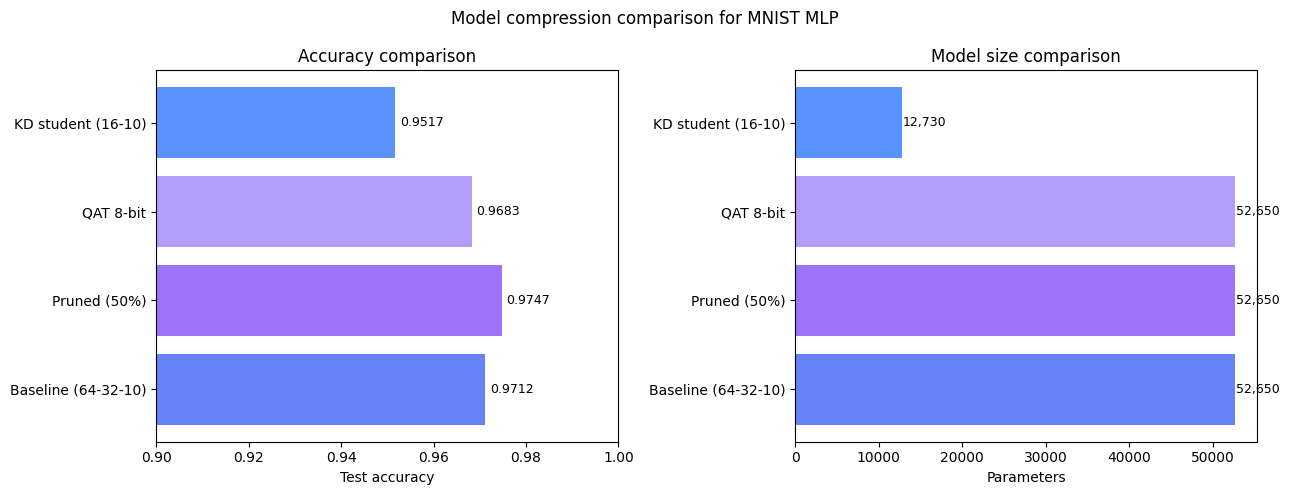

In [10]:
models = {
    'Baseline (64-32-10)': (acc,     baseline.count_params()),
    'Pruned (50%)':        (acc_pruned, pruned_stripped.count_params()),
    'QAT 8-bit':           (acc_qat, qat_model.count_params()),
    'KD student (16-10)':  (acc_kd,  student.count_params()),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names  = list(models.keys())
accs   = [v[0] for v in models.values()]
params = [v[1] for v in models.values()]
colors = ['#4B6CF7', '#8B5CF6', '#A78BFA', '#3C80FF']

axes[0].barh(names, accs,   color=colors, alpha=0.85)
axes[0].set_xlabel('Test accuracy')
axes[0].set_title('Accuracy comparison')
axes[0].set_xlim(0.9, 1.0)
for i, v in enumerate(accs):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(names, params, color=colors, alpha=0.85)
axes[1].set_xlabel('Parameters')
axes[1].set_title('Model size comparison')
for i, v in enumerate(params):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Model compression comparison for MNIST MLP', fontsize=12)
plt.tight_layout()
plt.show()

---

### Summary

- **Pruning** at 50% sparsity preserves >99% of baseline accuracy
- **QAT at 8-bit** maintains accuracy within 0.5% of the baseline
- **KD** produces a model with 70%+ fewer parameters at comparable accuracy
- In KalEdge, all three are available as standalone training tabs and pipeline combinations



---

### Bonus: Quantization-Aware Pruning

In [11]:
from qkeras import QDense, QActivation
from qkeras.quantizers import quantized_bits

WBITS = 8
IBITS = 0
NUM_CLASSES = 10


pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.5,
        begin_step=0,
        end_step=len(X_train)//64 * 10  # 10 epochs
    )
}


def build_qap_model(wbits=WBITS, ibits=IBITS, num_classes=NUM_CLASSES):
    model = tf.keras.Sequential([
        tfmot.sparsity.keras.prune_low_magnitude(
            QDense(64, input_shape=(784,),
                   kernel_quantizer=quantized_bits(wbits, ibits),
                   bias_quantizer=quantized_bits(wbits, ibits)),
            **pruning_params
        ),
        QActivation(f'quantized_relu({wbits},{ibits})'),

        tfmot.sparsity.keras.prune_low_magnitude(
            QDense(32,
                   kernel_quantizer=quantized_bits(wbits, ibits),
                   bias_quantizer=quantized_bits(wbits, ibits)),
            **pruning_params
        ),
        QActivation(f'quantized_relu({wbits},{ibits})'),

        tfmot.sparsity.keras.prune_low_magnitude(
            QDense(num_classes,
                   kernel_quantizer=quantized_bits(wbits, ibits),
                   bias_quantizer=quantized_bits(wbits, ibits),
                   activation='softmax'),
            **pruning_params
        ),
    ])
    return model

qat_pruned_model = build_qap_model()
qat_pruned_model.compile(optimizer='adam', 
                         loss='categorical_crossentropy', 
                         metrics=['accuracy'])


callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]


qat_pruned_model.fit(X_train, y_train_cat,
                     validation_data=(X_val, y_val_cat),
                     epochs=10, batch_size=64, verbose=1,
                     callbacks=callbacks)

acc_qap = qat_pruned_model.evaluate(X_te, y_test_cat, verbose=0)[1]
print(f'QAP accuracy (bits={WBITS}, ibits={IBITS}) : {acc_qap:.4f}')

qat_pruned_model = tfmot.sparsity.keras.strip_pruning(qat_pruned_model)

Epoch 1/10
844/844 [==============================] - 7s 4ms/step - loss: 0.4583 - accuracy: 0.8971 - val_loss: 0.2085 - val_accuracy: 0.9470
Epoch 2/10
844/844 [==============================] - 3s 4ms/step - loss: 0.1583 - accuracy: 0.9578 - val_loss: 0.1486 - val_accuracy: 0.9595
Epoch 3/10
844/844 [==============================] - 3s 4ms/step - loss: 0.1133 - accuracy: 0.9693 - val_loss: 0.1382 - val_accuracy: 0.9623
Epoch 4/10
844/844 [==============================] - 3s 4ms/step - loss: 0.0922 - accuracy: 0.9757 - val_loss: 0.1262 - val_accuracy: 0.9643
Epoch 5/10
844/844 [==============================] - 3s 4ms/step - loss: 0.0776 - accuracy: 0.9797 - val_loss: 0.1140 - val_accuracy: 0.9688
Epoch 6/10
844/844 [==============================] - 3s 4ms/step - loss: 0.0672 - accuracy: 0.9826 - val_loss: 0.1158 - val_accuracy: 0.9685
Epoch 7/10
844/844 [==============================] - 3s 4ms/step - loss: 0.0605 - accuracy: 0.9847 - val_loss: 0.1234 - val_accuracy: 0.9652
Epoch 

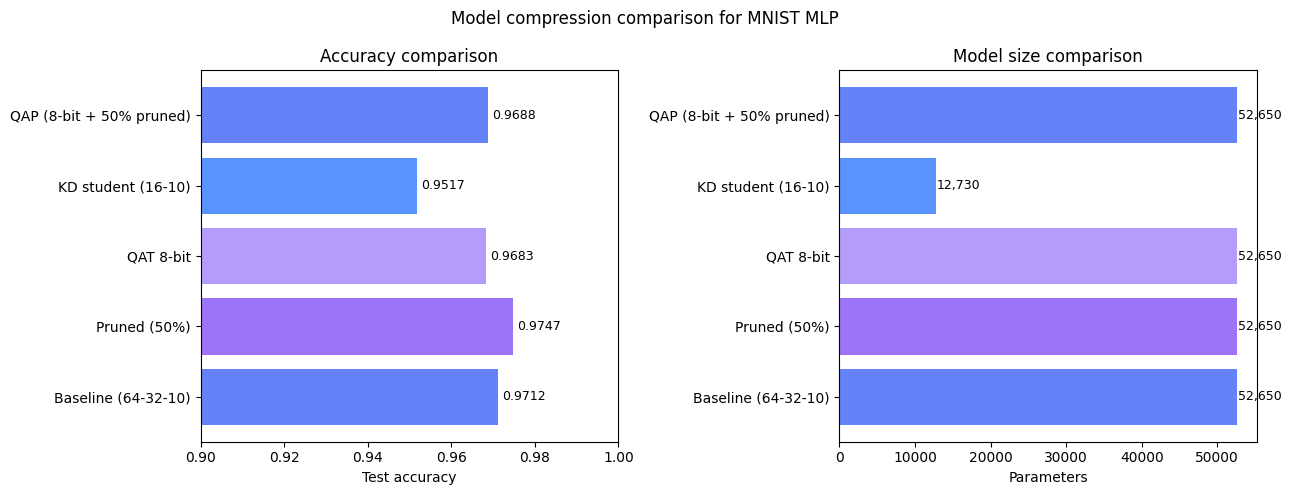

In [12]:
models = {
    'Baseline (64-32-10)': (acc, baseline.count_params()),
    'Pruned (50%)':        (acc_pruned, pruned_stripped.count_params()),
    'QAT 8-bit':           (acc_qat, qat_model.count_params()),
    'KD student (16-10)':  (acc_kd,  student.count_params()),
    'QAP (8-bit + 50% pruned)': (acc_qap, qat_pruned_model.count_params()),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names  = list(models.keys())
accs   = [v[0] for v in models.values()]
params = [v[1] for v in models.values()]
colors = ['#4B6CF7', '#8B5CF6', '#A78BFA', '#3C80FF']

axes[0].barh(names, accs,   color=colors, alpha=0.85)
axes[0].set_xlabel('Test accuracy')
axes[0].set_title('Accuracy comparison')
axes[0].set_xlim(0.9, 1.0)
for i, v in enumerate(accs):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(names, params, color=colors, alpha=0.85)
axes[1].set_xlabel('Parameters')
axes[1].set_title('Model size comparison')
for i, v in enumerate(params):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Model compression comparison for MNIST MLP', fontsize=12)
plt.tight_layout()
plt.show()

---



#### Exercise pruning:

Modify the value of final_sparsity (0.1, 0.3, 0.5, 0.7, 0.9) and report the evaluation metrics for each pruned model.

- What conclusions can you draw regarding the relationship between sparsity level, model performance, and efficiency?


#### Pruning Results Summary

| Experiment | Final Sparsity | Train Accuracy | Validation Accuracy | Test Accuracy | Observations |
|-----------|----------------|----------------|---------------------|---------------|--------------|
| 1 | 0.1 | | | | |
| 2 | 0.3 | | | | |
| 3 | 0.5 | | | | |
| 4 | 0.7 | | | | |
| 5 | 0.9 | | | | |


**Guiding questions:**
- At what sparsity level does accuracy start to degrade significantly?
- Is there a sparsity range where efficiency improves with minimal loss in performance?
- How does aggressive pruning affect training stability and convergence?



--- 


#### Exercise Quantization:

- Modify the bit-width (4, 8, 16, 32) and report the metrics for each model, considering both QAT and QAP. What conclusions can you draw?

- Modify the MLP architecture by increasing or decreasing the number of layers, and replace the Flatten layer with a Dense layer.

--- 

#### Exercises Knowledge Distillation 

- Vary the **student model architecture** and analyze the performance of the distilled model using the appropriate evaluation metrics. Consider the following scenarios:
  
  - Decrease the number of layers.
  - Vary the number of neurons in each layer.
  - Increase the number of layers while reducing the number of neurons per layer.

- Repeat the **model compression processes** for the **Fashion-MNIST** and **CIFAR-10** datasets.


### Results Summary Table

| Experiment | Dataset | Model Type | # Layers | Neurons per Layer | Compression Method | Bit-width | Final Sparsity | Train Accuracy | Validation Accuracy | Test Accuracy | Model Size / Params | Observations |
|-----------|---------|------------|----------|-------------------|--------------------|-----------|----------------|----------------|---------------------|---------------|---------------------|--------------|
| 1 | MNIST | Student (baseline) | | | None | FP32 | – | | | | | |
| 2 | MNIST | Student | | | QAT | 8 | – | | | | | |
| 3 | MNIST | Student | | | QAP | 8 | 0.3 | | | | | |
| 4 | MNIST | Student | | | Distillation -> QAT | 8 | – | | | | | |
| 5 | Fashion-MNIST | Student | | | QAT | 8 | – | | | | | |
| 6 | Fashion-MNIST | Student | | | QAP | 8 | 0.3 | | | | | |
| 7 | CIFAR-10 | Student | | | QAT | 8 | – | | | | | |
| 8 | CIFAR-10 | Student | | | Distillation -> QAT | 8 | – | | | | | |


**Guiding Questions:**
- How does reducing the number of layers affect accuracy and generalization?
- Is it more effective to reduce depth or width when compressing the model?
- At what point does compression significantly degrade performance?
- Does knowledge distillation help recover accuracy lost due to quantization or pruning?
- Which configuration offers the best trade-off between accuracy and efficiency?

